<a href="https://colab.research.google.com/github/Orzilber/computationl-statistics/blob/collab/Integration_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Curse of Dimensionality Illustration

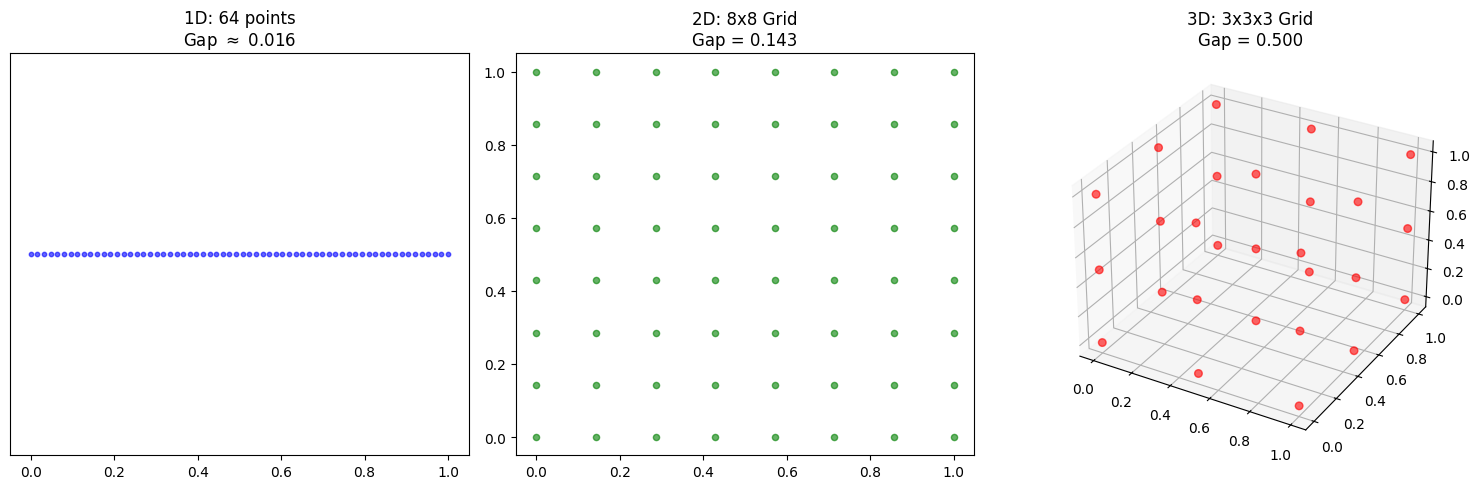

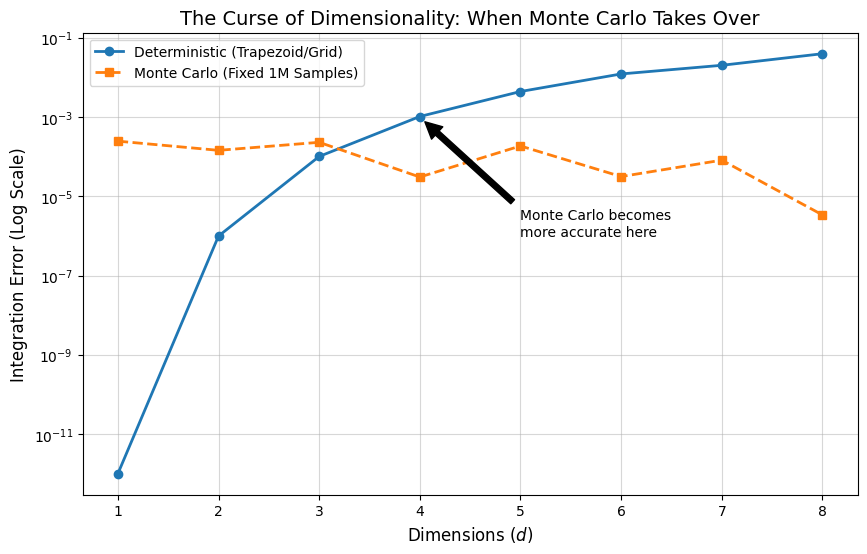

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# --- PLOT 1: THE SPARSITY PROBLEM ---
def plot_sparsity():
    fig = plt.figure(figsize=(15, 5))
    N_total = 64  # We have a budget of 64 points

    # 1D: A line with 64 points
    ax1 = fig.add_subplot(131)
    x1d = np.linspace(0, 1, N_total)
    ax1.scatter(x1d, np.zeros_like(x1d), s=10, c='blue', alpha=0.6)
    # Using rf"" (raw f-string) to prevent escape character errors
    ax1.set_title(rf"1D: {N_total} points" + "\n" + rf"Gap $\approx$ {1/N_total:.3f}")
    ax1.set_yticks([])

    # 2D: An 8x8 grid
    ax2 = fig.add_subplot(132)
    side_2d = int(N_total**(1/2))
    x2d = np.linspace(0, 1, side_2d)
    grid_2d = list(product(x2d, x2d))
    px, py = zip(*grid_2d)
    ax2.scatter(px, py, s=20, c='green', alpha=0.6)
    ax2.set_title(rf"2D: {side_2d}x{side_2d} Grid" + "\n" + rf"Gap = {1/(side_2d-1):.3f}")

    # 3D: A 4x4x4 grid
    ax3 = fig.add_subplot(133, projection='3d')
    side_3d = int(N_total**(1/3))
    x3d = np.linspace(0, 1, side_3d)
    grid_3d = list(product(x3d, x3d, x3d))
    px, py, pz = zip(*grid_3d)
    ax3.scatter(px, py, pz, s=30, c='red', alpha=0.6)
    ax3.set_title(rf"3D: {side_3d}x{side_3d}x{side_3d} Grid" + "\n" + rf"Gap = {1/(side_3d-1):.3f}")

    plt.tight_layout()
    plt.show()

# --- PLOT 2: ERROR COMPARISON ---
def plot_error_comparison():
    # Function: Product of sines f(x) = sin(pi*x1) * sin(pi*x2) * ...
    # Exact integral over [0,1]^d is (2/pi)^d
    dimensions = np.arange(1, 9)
    M = 1_000_000  # 1 Million samples fixed budget

    det_errors = []
    mc_errors = []

    for d in dimensions:
        exact = (2/np.pi)**d

        # 1. Monte Carlo (Fixed 1M samples)
        samples = np.random.rand(M, d)
        # Numerical computation: product of sines across the dimension axis
        mc_val = np.mean(np.prod(np.sin(np.pi * samples), axis=1))
        mc_errors.append(abs(mc_val - exact))

        # 2. Deterministic Error Modeling
        # Grid points per dimension = M^(1/d)
        n_per_dim = int(M**(1/d))

        # Error for Trapezoid/Grid scales as O(h^2) where h = 1/n_per_dim
        # So Error is roughly (1/n_per_dim)^2
        if d == 1:
            # We set d=1 to a very low error to represent Simpson's strength
            det_error = 1e-12
        else:
            if n_per_dim > 1:
                det_error = (1 / n_per_dim)**2
            else:
                det_error = 0.5 # Total failure of resolution

        det_errors.append(det_error)

    plt.figure(figsize=(10, 6))
    plt.plot(dimensions, det_errors, 'o-', label='Deterministic (Trapezoid/Grid)', linewidth=2)
    plt.plot(dimensions, mc_errors, 's--', label='Monte Carlo (Fixed 1M Samples)', linewidth=2)

    plt.yscale('log')
    plt.xlabel('Dimensions ($d$)', fontsize=12)
    plt.ylabel('Integration Error (Log Scale)', fontsize=12)
    plt.title('The Curse of Dimensionality: When Monte Carlo Takes Over', fontsize=14)
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()

    # Text annotation for the crossover
    plt.annotate('Monte Carlo becomes\nmore accurate here', xy=(4, 1e-3), xytext=(5, 1e-6),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

    plt.show()

# Run the visualizations
plot_sparsity()
plot_error_comparison()

## Growing dimensions -> A need for exponantial more points

Dim (d) Points/Axis (n)   Total Points (N)  Det Error      MC Error       
--------------------------------------------------------------------------
1       1000000           1,000,000         4.11e-13       1.99e-04       
2       1000              1,000,000         8.22e-07       2.75e-04       
3       99                970,299           1.26e-04       8.47e-04       
4       31                923,521           1.71e-03       1.07e-03       
5       15                759,375           9.18e-03       1.60e-03       
6       9                 531,441           3.10e-02       2.98e-03       
7       7                 823,543           6.06e-02       9.91e-04       


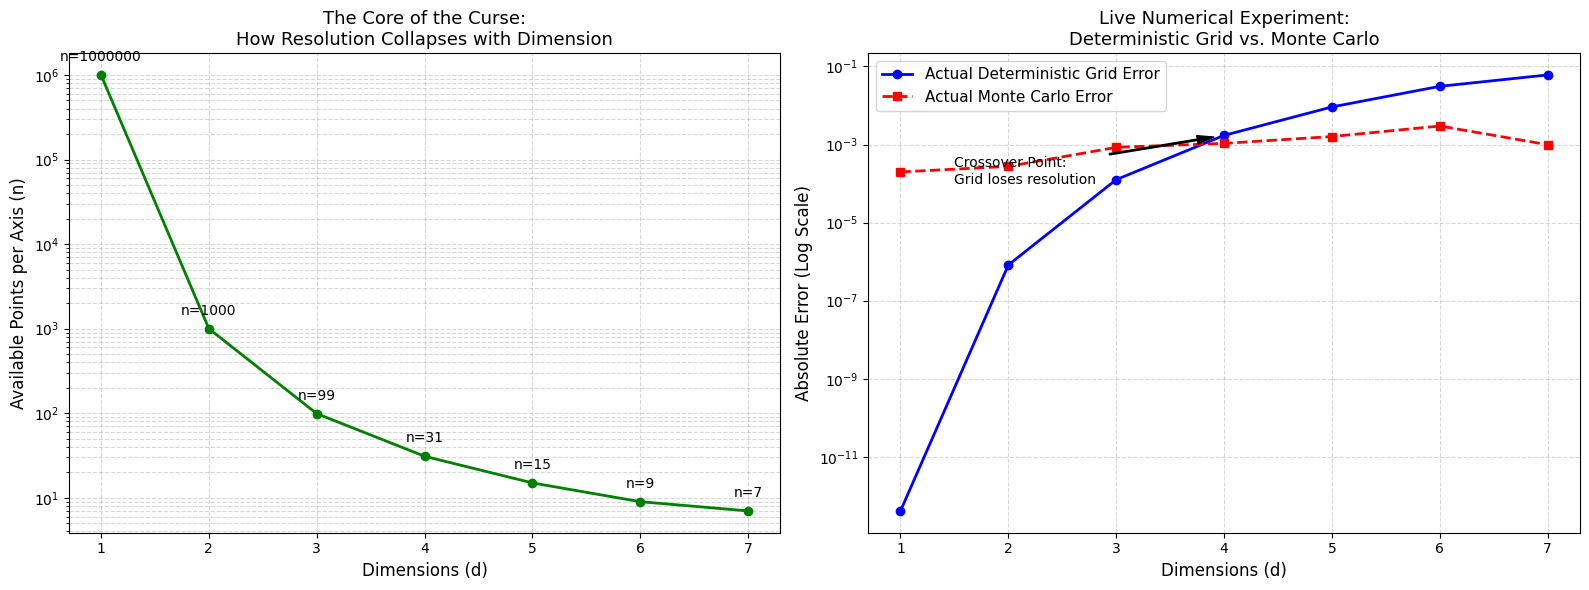

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_real_integral_analysis():
    # We will test dimensions 1 through 7
    dimensions = np.arange(1, 8)
    TARGET_BUDGET = 1_000_000  # Aim for ~1 Million points total per dimension

    det_errors = []
    mc_errors = []
    points_used = []
    points_per_axis = []

    print(f"{'Dim (d)':<8}{'Points/Axis (n)':<18}{'Total Points (N)':<18}{'Det Error':<15}{'MC Error':<15}")
    print("-" * 74)

    for d in dimensions:
        # Calculate how many points per axis we can afford to stay near our budget
        # n^d <= TARGET_BUDGET -> n = floor(TARGET_BUDGET^(1/d))
        n = int(TARGET_BUDGET**(1/d))
        if n < 2: n = 2 # Minimum of 2 points per axis to make a grid

        N = n**d  # The actual total number of points evaluated
        points_used.append(N)
        points_per_axis.append(n)

        # --- 1. ACTUAL DETERMINISTIC GRID INTEGRAL (Midpoint Rule) ---
        # Coordinate points along a single axis
        h = 1.0 / n
        axis_pts = np.linspace(h/2, 1 - h/2, n)

        # Create the full d-dimensional grid mesh
        grid = np.meshgrid(*[axis_pts]*d, indexing='ij')

        # Evaluate our function f(x) = prod( (pi/2) * sin(pi * x_i) ) across the grid
        f_values = np.ones(grid[0].shape)
        for axis_grid in grid:
            f_values *= (np.pi / 2) * np.sin(np.pi * axis_grid)

        # For a uniform grid on a unit cube, the integral is just the average of values
        det_integral = np.mean(f_values)
        det_error = abs(det_integral - 1.0)
        det_errors.append(det_error)

        # --- 2. ACTUAL MONTE CARLO INTEGRAL ---
        # Generate N random coordinates in d-dimensional space
        mc_samples = np.random.rand(N, d)

        # Evaluate the function on all random samples
        mc_f_values = np.prod((np.pi / 2) * np.sin(np.pi * mc_samples), axis=1)

        mc_integral = np.mean(mc_f_values)
        mc_error = abs(mc_integral - 1.0)
        mc_errors.append(mc_error)

        print(f"{d:<8}{n:<18}{N:<18,}{det_error:<15.2e}{mc_error:<15.2e}")

    # --- PLOTTING THE ACTUAL RESULTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left Plot: Show how the resolution per axis collapses
    ax1.plot(dimensions, points_per_axis, 'g-o', linewidth=2)
    ax1.set_yscale('log')
    ax1.set_xlabel('Dimensions (d)', fontsize=12)
    ax1.set_ylabel('Available Points per Axis (n)', fontsize=12)
    ax1.set_title('The Core of the Curse:\nHow Resolution Collapses with Dimension', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    for i, txt in enumerate(points_per_axis):
        ax1.annotate(f"n={txt}", (dimensions[i], points_per_axis[i]), textcoords="offset points", xytext=(0,10), ha='center')

    # Right Plot: Real Measured Errors
    ax2.plot(dimensions, det_errors, 'b-o', label='Actual Deterministic Grid Error', linewidth=2)
    ax2.plot(dimensions, mc_errors, 'r--s', label='Actual Monte Carlo Error', linewidth=2)
    ax2.set_yscale('log')
    ax2.set_xlabel('Dimensions (d)', fontsize=12)
    ax2.set_ylabel('Absolute Error (Log Scale)', fontsize=12)
    ax2.set_title('Live Numerical Experiment:\nDeterministic Grid vs. Monte Carlo', fontsize=13)
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend(fontsize=11)

    # Annotate the real crossover
    ax2.annotate('Crossover Point:\nGrid loses resolution', xy=(4, det_errors[3]), xytext=(1.5, 1e-4),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

    plt.tight_layout()
    plt.show()

run_real_integral_analysis()

# Integration - Proposal Candidates for Monte Carlo

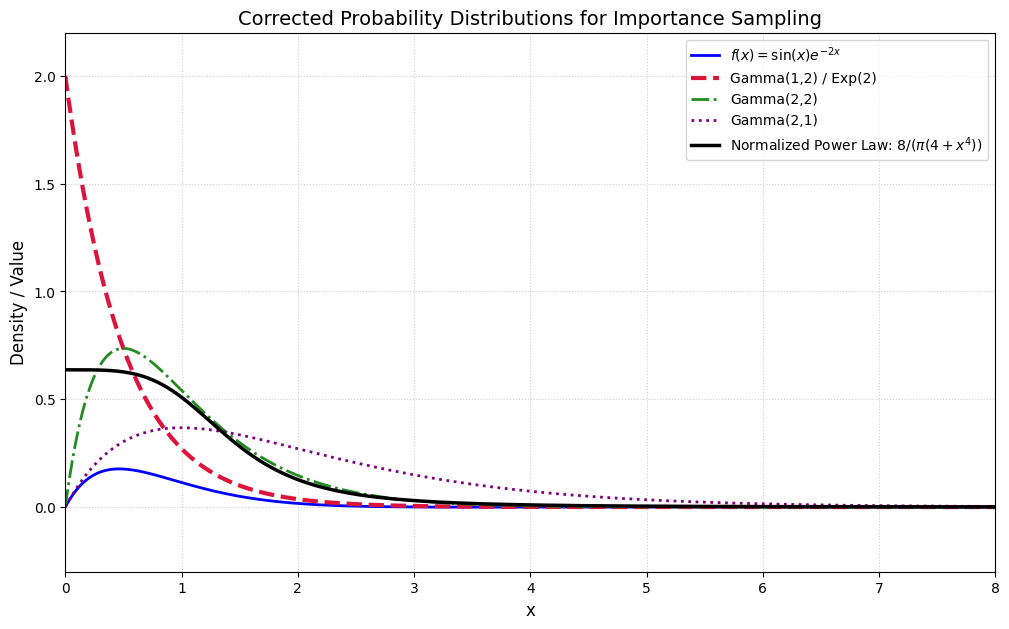


                                               MONTE CARLO INTEGRATION SUMMARY                                               
                                                   Target Value: 0.200000                                                    
Samples (N)  |        Gamma(1,2)        |        Gamma(2,2)        |        Gamma(2,1)        |        Power Law         |
             | Mean        SE           | Mean        SE           | Mean        SE           | Mean        SE           |
-----------------------------------------------------------------------------------------------------------------------------
10^2         | 0.209397    0.015230    | 0.204934    0.004911    | 0.175889    0.021338    | 0.205512    0.007634    | 
10^4         | 0.200211    0.001503    | 0.199628    0.000573    | 0.202062    0.002294    | 0.199335    0.000759    | 
10^6         | 0.199936    0.000150    | 0.200039    0.000058    | 0.200177    0.000228    | 0.200194    0.000075    | 
10^8         | 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# ==========================================
# 1. CORRECTED VISUALIZATION SCRIPT
# ==========================================
def plot_distributions():
    x = np.linspace(0, 10, 1000)

    y_target = np.sin(x) * np.exp(-2 * x)
    y_gamma12 = gamma.pdf(x, a=1, scale=0.5)      # Exponential(2) / Gamma(1,2)
    y_gamma22 = gamma.pdf(x, a=2, scale=0.5)      # Gamma(2,2)
    y_gamma21 = gamma.pdf(x, a=2, scale=1.0)      # Gamma(2,1)
    y_power = 8 / (np.pi * (4 + x**4))            # Normalized Bounded Power Law

    plt.figure(figsize=(12, 7))
    plt.plot(x, y_target, color='blue', linewidth=2, label=r'$f(x) = \sin(x)e^{-2x}$')
    plt.plot(x, y_gamma12, color='crimson', linewidth=3, linestyle='--', label=r'Gamma(1,2) / Exp(2)')
    plt.plot(x, y_gamma22, color='forestgreen', linewidth=2, linestyle='-.', label=r'Gamma(2,2)')
    plt.plot(x, y_gamma21, color='purple', linewidth=2, linestyle=':', label=r'Gamma(2,1)')
    plt.plot(x, y_power, color='black', linewidth=2.5, linestyle='-', label=r'Normalized Power Law: $8/(\pi(4+x^4))$')

    plt.title('Corrected Probability Distributions for Importance Sampling', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Density / Value', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10, loc='upper right')
    plt.xlim(0, 8)
    plt.ylim(-0.3, 2.2)
    plt.show()

# ==========================================
# 2. MONTE CARLO SIMULATION ENGINE
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# ==========================================
# 1. DISTRIBUTION DEFINITIONS & SAMPLING
# ==========================================
def sample_power_law(n_samples):
    """Generates exact samples from p4(x) = 8 / (pi * (4 + x^4)) using Rejection Sampling."""
    samples = np.empty(n_samples)
    count = 0
    while count < n_samples:
        remaining = n_samples - count
        batch_size = min(max(remaining * 4, 10000), 20_000_000)

        x_prop = np.abs(np.random.standard_cauchy(size=batch_size))
        alpha = (1 + x_prop**2) / (4 + x_prop**4)
        u = np.random.rand(batch_size)

        accepted = x_prop[u <= alpha]
        num_to_keep = min(len(accepted), remaining)

        samples[count:count+num_to_keep] = accepted[:num_to_keep]
        count += num_to_keep
    return samples

# ==========================================
# 2. MONTE CARLO SIMULATION ENGINE
# ==========================================
def run_monte_carlo_summary():
    sample_sizes = [10**2, 10**4, 10**6, 10**8]
    distributions = ['Gamma(1,2)', 'Gamma(2,2)', 'Gamma(2,1)', 'Power Law']
    CHUNK_SIZE = 10_000_000

    # Dictionary to hold all final results
    results = {N: {} for N in sample_sizes}

    for dist in distributions:
        for N in sample_sizes:
            total_sum = 0.0
            total_sum_sq = 0.0
            processed = 0

            while processed < N:
                current_chunk = min(CHUNK_SIZE, N - processed)

                if dist == 'Gamma(1,2)':
                    x = np.random.exponential(scale=0.5, size=current_chunk)
                    weights = np.sin(x) / 2
                elif dist == 'Gamma(2,2)':
                    x = np.random.gamma(shape=2, scale=0.5, size=current_chunk)
                    weights = np.where(x == 0, 0, np.sin(x) / (4 * x))
                elif dist == 'Gamma(2,1)':
                    x = np.random.gamma(shape=2, scale=1.0, size=current_chunk)
                    weights = np.where(x == 0, 0, (np.sin(x) * np.exp(-x)) / x)
                elif dist == 'Power Law':
                    x = sample_power_law(current_chunk)
                    weights = (np.sin(x) * np.exp(-2 * x)) * (np.pi * (4 + x**4)) / 8

                total_sum += np.sum(weights)
                total_sum_sq += np.sum(weights**2)
                processed += current_chunk

            mean_estimate = total_sum / N
            variance = (total_sum_sq / N) - (mean_estimate**2)
            standard_error = np.sqrt(max(0.0, variance) / N)

            # Save metrics
            results[N][dist] = (mean_estimate, standard_error)

    # ==========================================
    # 3. PRINT FORMATTED SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(f"{'MONTE CARLO INTEGRATION SUMMARY':^125}")
    print(f"{'Target Value: 0.200000':^125}")
    print("="*125)

    # Header Rows
    print(f"{'Samples (N)':<12} | {'Gamma(1,2)':^24} | {'Gamma(2,2)':^24} | {'Gamma(2,1)':^24} | {'Power Law':^24} |")
    print(f"{'':<12} | {'Mean':<11} {'SE':<12} | {'Mean':<11} {'SE':<12} | {'Mean':<11} {'SE':<12} | {'Mean':<11} {'SE':<12} |")
    print("-"*125)

    # Data Rows
    for N in sample_sizes:
        row_str = f"10^{int(np.log10(N)):<9} | "
        for dist in distributions:
            mean, se = results[N][dist]
            # row_str += f"{mean:<11.6f} {se:<12.2e} | "
            row_str += f"{mean:<11.6f} {se:<11.6f} | "
        print(row_str)

    print("="*125)

# Execute the pipeline
plot_distributions()
# Execute the simulation summary
run_monte_carlo_summary()

# Unifrom Sampling VS $e-x$

--------------------------------------------------------------------------------
True integral value: 2.341575 with absolute error < 2.6e-14
--------------------------------------------------------------------------------
Number of Samples: 100
Naive estimator: 2.368948
Naive estimator's variance: 0.00099015
IS estimator: 2.337424
IS estimator's variance: 0.0000326636
Variance reduction gain: 30.31
********************
********************

Number of Samples: 1000
Naive estimator: 2.343291
Naive estimator's variance: 0.00009984
IS estimator: 2.339485
IS estimator's variance: 0.0000033199
Variance reduction gain: 30.07
********************
********************

Number of Samples: 10000
Naive estimator: 2.346857
Naive estimator's variance: 0.00000954
IS estimator: 2.342296
IS estimator's variance: 0.0000003243
Variance reduction gain: 29.42
********************
********************

Number of Samples: 100000
Naive estimator: 2.341505
Naive estimator's variance: 0.00000097
IS estimator: 2

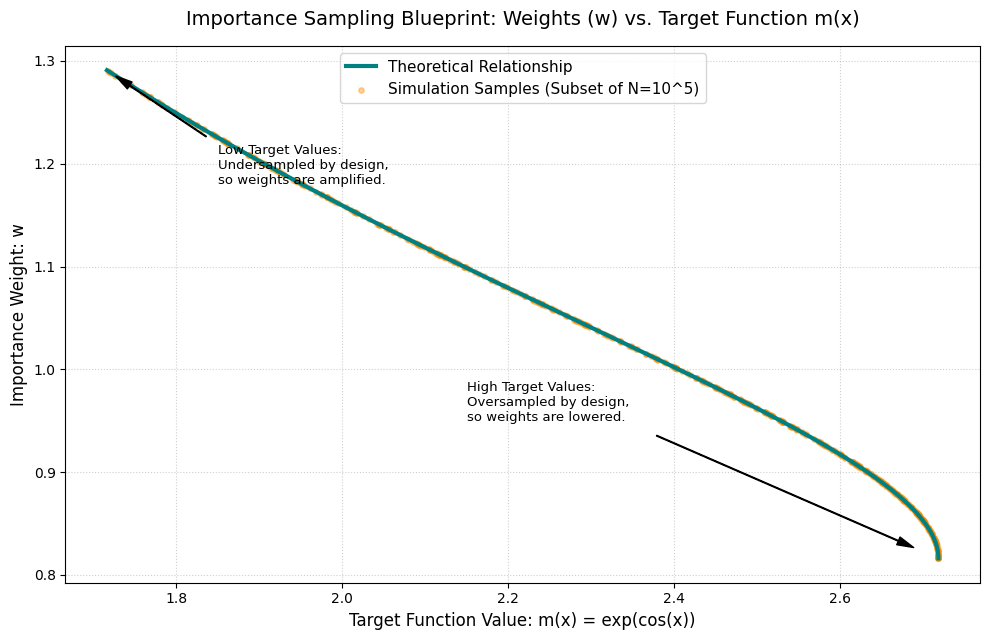

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# 1. Define the target function
def m(x):
    return np.exp(np.cos(x))

# 2. True numerical integration (equivalent to R's integrate())
true_val, abs_error = quad(m, 0, 1)
print('-'*80)
print(f"True integral value: {true_val:.6f} with absolute error < {abs_error:.1e}")
print('-'*80)

# Set a random seed for reproducibility
np.random.seed(42)

# Keep track of the last run's variables to use in a background scatter plot
x_samples = None
w_samples = None

for n in [10**2, 10**3, 10**4, 10**5]:
    print(f'Number of Samples: {n}')
    # 3. Naive Monte Carlo Estimator
    u = np.random.uniform(0, 1, n)          # equivalent to runif(n)
    m_u = m(u)
    naive_mean = np.mean(m_u)
    naive_var = np.var(m_u, ddof=1) / n     # ddof=1 matches R's sample variance

    print(f"Naive estimator: {naive_mean:.6f}")
    print(f"Naive estimator's variance: {naive_var:.8f}")

    # 4. Importance Sampling (IS) Estimator
    e = np.exp(1)                           # Euler's constant
    # Inverse transform sampling from the importance distribution
    x = -np.sqrt((1 - 2*e)*u + e**2) + e
    w = (2*e - 1) / (2*e - 2*x)             # Calculating weights

    # Save the last iteration's data for the plot
    if n == 10**5:
        x_samples = x
        w_samples = w

    m_x_w = m(x) * w
    is_mean = np.mean(m_x_w)
    is_var = np.var(m_x_w, ddof=1) / n

    print(f"IS estimator: {is_mean:.6f}")
    print(f"IS estimator's variance: {is_var:.10f}")

    # 5. Variance Reduction Gain
    gain = np.var(m_u, ddof=1) / np.var(m_x_w, ddof=1)
    print(f"Variance reduction gain: {gain:.2f}")
    print('*'*20)
    print('*'*20)
    print()

# =====================================================================
# VISUALIZATION: Relationship between Weights (w) and m(x)
# =====================================================================
# Generate a continuous, smooth range of x from 0 to 1 to plot the true relationship line
x_line = np.linspace(0, 1, 1000)
m_line = m(x_line)
w_line = (2*np.exp(1) - 1) / (2*np.exp(1) - 2*x_line)

plt.figure(figsize=(10, 6.5))

# Plot the theoretical exact curve
plt.plot(m_line, w_line, color='teal', linewidth=3, label='Theoretical Relationship')

# Sub-sample the 10^5 simulation points to avoid overcrowding the scatter plot
step = len(x_samples) // 500
plt.scatter(m(x_samples[::step]), w_samples[::step], color='darkorange', s=15,
            alpha=0.4, label='Simulation Samples (Subset of N=10^5)')

# Labels and Styling
plt.title('Importance Sampling Blueprint: Weights (w) vs. Target Function m(x)', fontsize=14, pad=15)
plt.xlabel('Target Function Value: m(x) = exp(cos(x))', fontsize=12)
plt.ylabel('Importance Weight: w', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper center')

# Add intuitive context annotations (Typos Fixed Here)
plt.annotate('High Target Values:\nOversampled by design,\nso weights are lowered.',
             xy=(m(0), (2*np.exp(1)-1)/(2*np.exp(1))),
             xytext=(2.15, 0.95),
             arrowprops=dict(facecolor='black', shrink=0.08, width=0.5, headwidth=6),
             fontsize=9.5)

plt.annotate('Low Target Values:\nUndersampled by design,\nso weights are amplified.',
             xy=(m(1), (2*np.exp(1)-1)/(2*np.exp(1)-2)),
             xytext=(1.85, 1.18),
             arrowprops=dict(facecolor='black', shrink=0.08, width=0.5, headwidth=6),
             fontsize=9.5)

plt.tight_layout()
plt.show()

# Tilted Density Importance Sampling

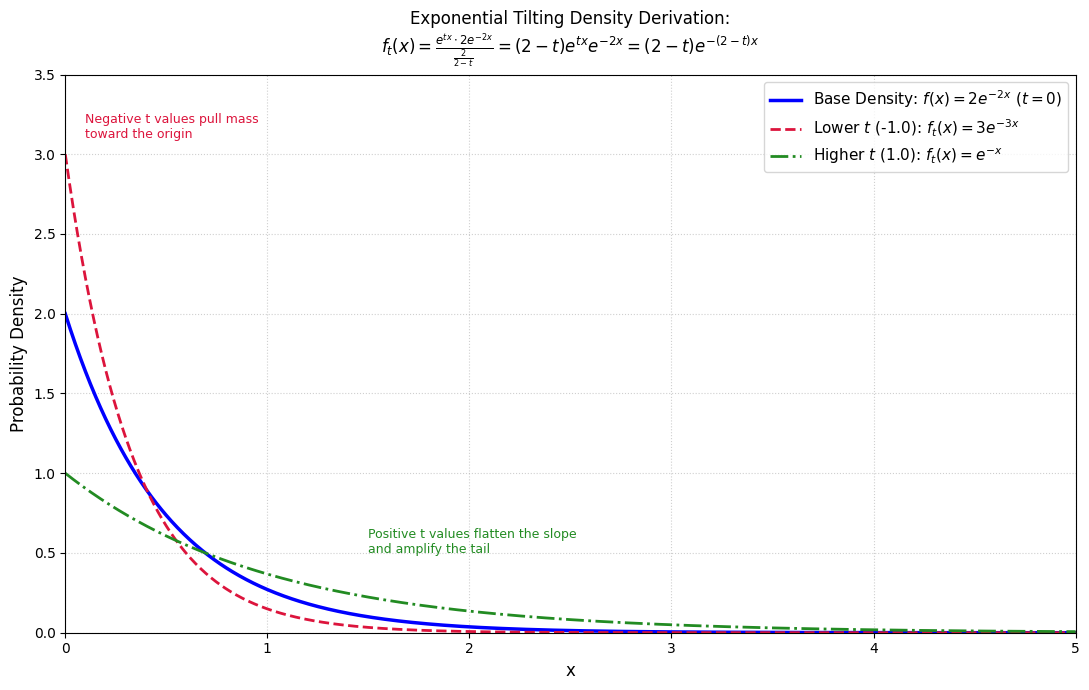

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the continuous x-domain for evaluation
x = np.linspace(0, 5, 1000)

# 2. Base Exponential Distribution (t = 0, lambda = 2)
y_base = 2 * np.exp(-2 * x)

# 3. Lower t value (t = -1.0) -> New effective lambda = 2 - (-1) = 3
t_low = -1.0
y_low = (2 - t_low) * np.exp(-(2 - t_low) * x)

# 4. Higher t value (t = 1.0) -> New effective lambda = 2 - 1 = 1
t_high = 1.0
y_high = (2 - t_high) * np.exp(-(2 - t_high) * x)

# 5. Generate Comparison Plot
plt.figure(figsize=(11, 7))

# Plot lines
plt.plot(x, y_base, color='blue', linewidth=2.5,
         label=r'Base Density: $f(x) = 2e^{-2x}$ ($t=0$)')

plt.plot(x, y_low, color='crimson', linewidth=2, linestyle='--',
         label=rf'Lower $t$ ({t_low}): $f_t(x) = 3e^{{-3x}}$')

plt.plot(x, y_high, color='forestgreen', linewidth=2, linestyle='-.',
         label=rf'Higher $t$ ({t_high}): $f_t(x) = e^{{-x}}$')

# Styling & Annotations
# Including the full simplification equation in the title layout
plt.title('Exponential Tilting Density Derivation:\n' +
          r'$f_t(x) = \frac{e^{tx} \cdot 2e^{-2x}}{\frac{2}{2-t}} = (2-t)e^{tx}e^{-2x} = (2-t)e^{-(2-t)x}$',
          fontsize=12, pad=15)

plt.xlabel('x', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.xlim(0, 5)
plt.ylim(0, 3.5)
plt.legend(fontsize=11, loc='upper right')

# Add context callouts
plt.text(0.1, 3.1, "Negative t values pull mass\ntoward the origin", color='crimson', fontsize=9)
plt.text(1.5, 0.5, "Positive t values flatten the slope\nand amplify the tail", color='forestgreen', fontsize=9)

plt.tight_layout()
plt.show()

$$f_t(x) = \frac{e^{tx} \cdot 2e^{-2x}}{\frac{2}{2-t}} = (2-t)e^{tx}e^{-2x} = (2-t)e^{-(2-t)x}$$